# Introduction

+ A churn model is a mathematical representation of how churn impacts your business. Churn calculations are built on existing data (the number of customers who left your service during a given time period). A predictive churn model extrapolates on this data to show future potential churn rates.

+ Churn (aka customer attrition) is a scourge on subscription businesses. When your revenue is based on recurring monthly or annual contracts, every customer who leaves puts a dent in your cash flow. High retention rates are vital for your survival. So what if we told you there was a way to predict, at least to some degree, how and when your customers will cancel?

+ Building a predictive churn model helps you make proactive changes to your retention efforts that drive down churn rates. Understanding how churn impacts your current revenue goals and making predictions about how to manage those issues in the future also helps you stem the flow of churned customers. If you don’t take action against your churn now, any company growth you experience simply won’t be sustainable.

+ Comprehensive customer profiles help you see what types of customers are canceling their accounts. Now it’s time to figure out how and why they’re churning. Ask yourself the following questions to learn more about the pain points in your product and customer experience that lead to a customer deciding to churn.

# What is customer churn?

+ Customer churn (or customer attrition) is a tendency of customers to abandon a brand and stop being a paying client of a particular business. The percentage of customers that discontinue using a company’s products or services during a particular time period is called a customer churn (attrition) rate. One of the ways to calculate a churn rate is to divide the number of customers lost during a given time interval by the number of acquired customers, and then multiply that number by 100 percent. For example, if you got 150 customers and lost three last month, then your monthly churn rate is 2 percent.

+ Churn rate is a health indicator for businesses whose customers are subscribers and paying for services on a recurring basis, thus, a customer stays open for more interesting or advantageous offers. Plus, each time their current commitment ends, customers have a chance to reconsider and choose not to continue with the company. Of course, some natural churn is inevitable, and the figure differs from industry to industry. But having a higher churn figure than that is a definite sign that a business is doing something wrong.”

+ There are many things brands may do wrong, from complicated onboarding when customers aren’t given easy-to-understand information about product usage and its capabilities to poor communication, e.g. the lack of feedback or delayed answers to queries. Another situation: Longtime clients may feel unappreciated because they don’t get as many bonuses as the new ones.

# Step 1: Importing the Data and Libraries

The first step, as always, is to import the required libraries. Execute the following code to do so:

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-card-customers/BankChurners.csv


In [2]:
data = pd.read_csv('../input/credit-card-customers/BankChurners.csv')

In [3]:
data.isnull().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

LUCKY! NO need to handle with NaN or missing data.

In [4]:
data.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [5]:
data.head(2)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994


Columns title is TO LONG, let's rename it.

In [6]:
old_names = data.columns
new_names = ['Clientnum', 'Attrition', 'Age', 'Gender', 'Dependent_count', 'Education', 'Marital_Status', 'Income', 
             'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive', 'Contacts_Count', 
             'Credit_Limit', 'Total_Revolving_Bal','Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
             'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio','Naive_Bayes_1','Naive_Bayes_2']
data.rename(columns=dict(zip(old_names, new_names)), inplace=True)

# Step 2. Exploratory data analysis

After preprocessing the data, it is analyzed through visual exploration to gather insights about the model that can be applied to the data, understand the diversity in the data and the range of every field. We use a bar chart, box plot, distribution graph, etc. to explore each feature varies and its relation with other features including the target feature.

Import basic Librairies.

In [7]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.style as style
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

In [8]:
data.head(2)

,Clientnum,Attrition,Age,Gender,Dependent_count,Education,Marital_Status,Income,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_1,Naive_Bayes_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994


Check to confirm if the Database is IMBALANCED? How?

In [9]:
#Churn vs. normal 
counts = data.Attrition.value_counts()
normal = counts[0]
Churn = counts[1]
perc_normal = (normal/(normal+Churn))*100
perc_Churn = (Churn/(normal+Churn))*100
print('There were {} non-Churn ({:.3f}%) and {} Churn ({:.3f}%).'.format(normal, perc_normal, Churn, perc_Churn))

There were 8500 non-Churn (83.934%) and 1627 Churn (16.066%).


The Dataset is IMBALANCED, but NOT typical, since I expected for this type should be something like: 98:2 or 99:1, NOT such 84:16 :). But, it's OK, let's dicover some illustrations.

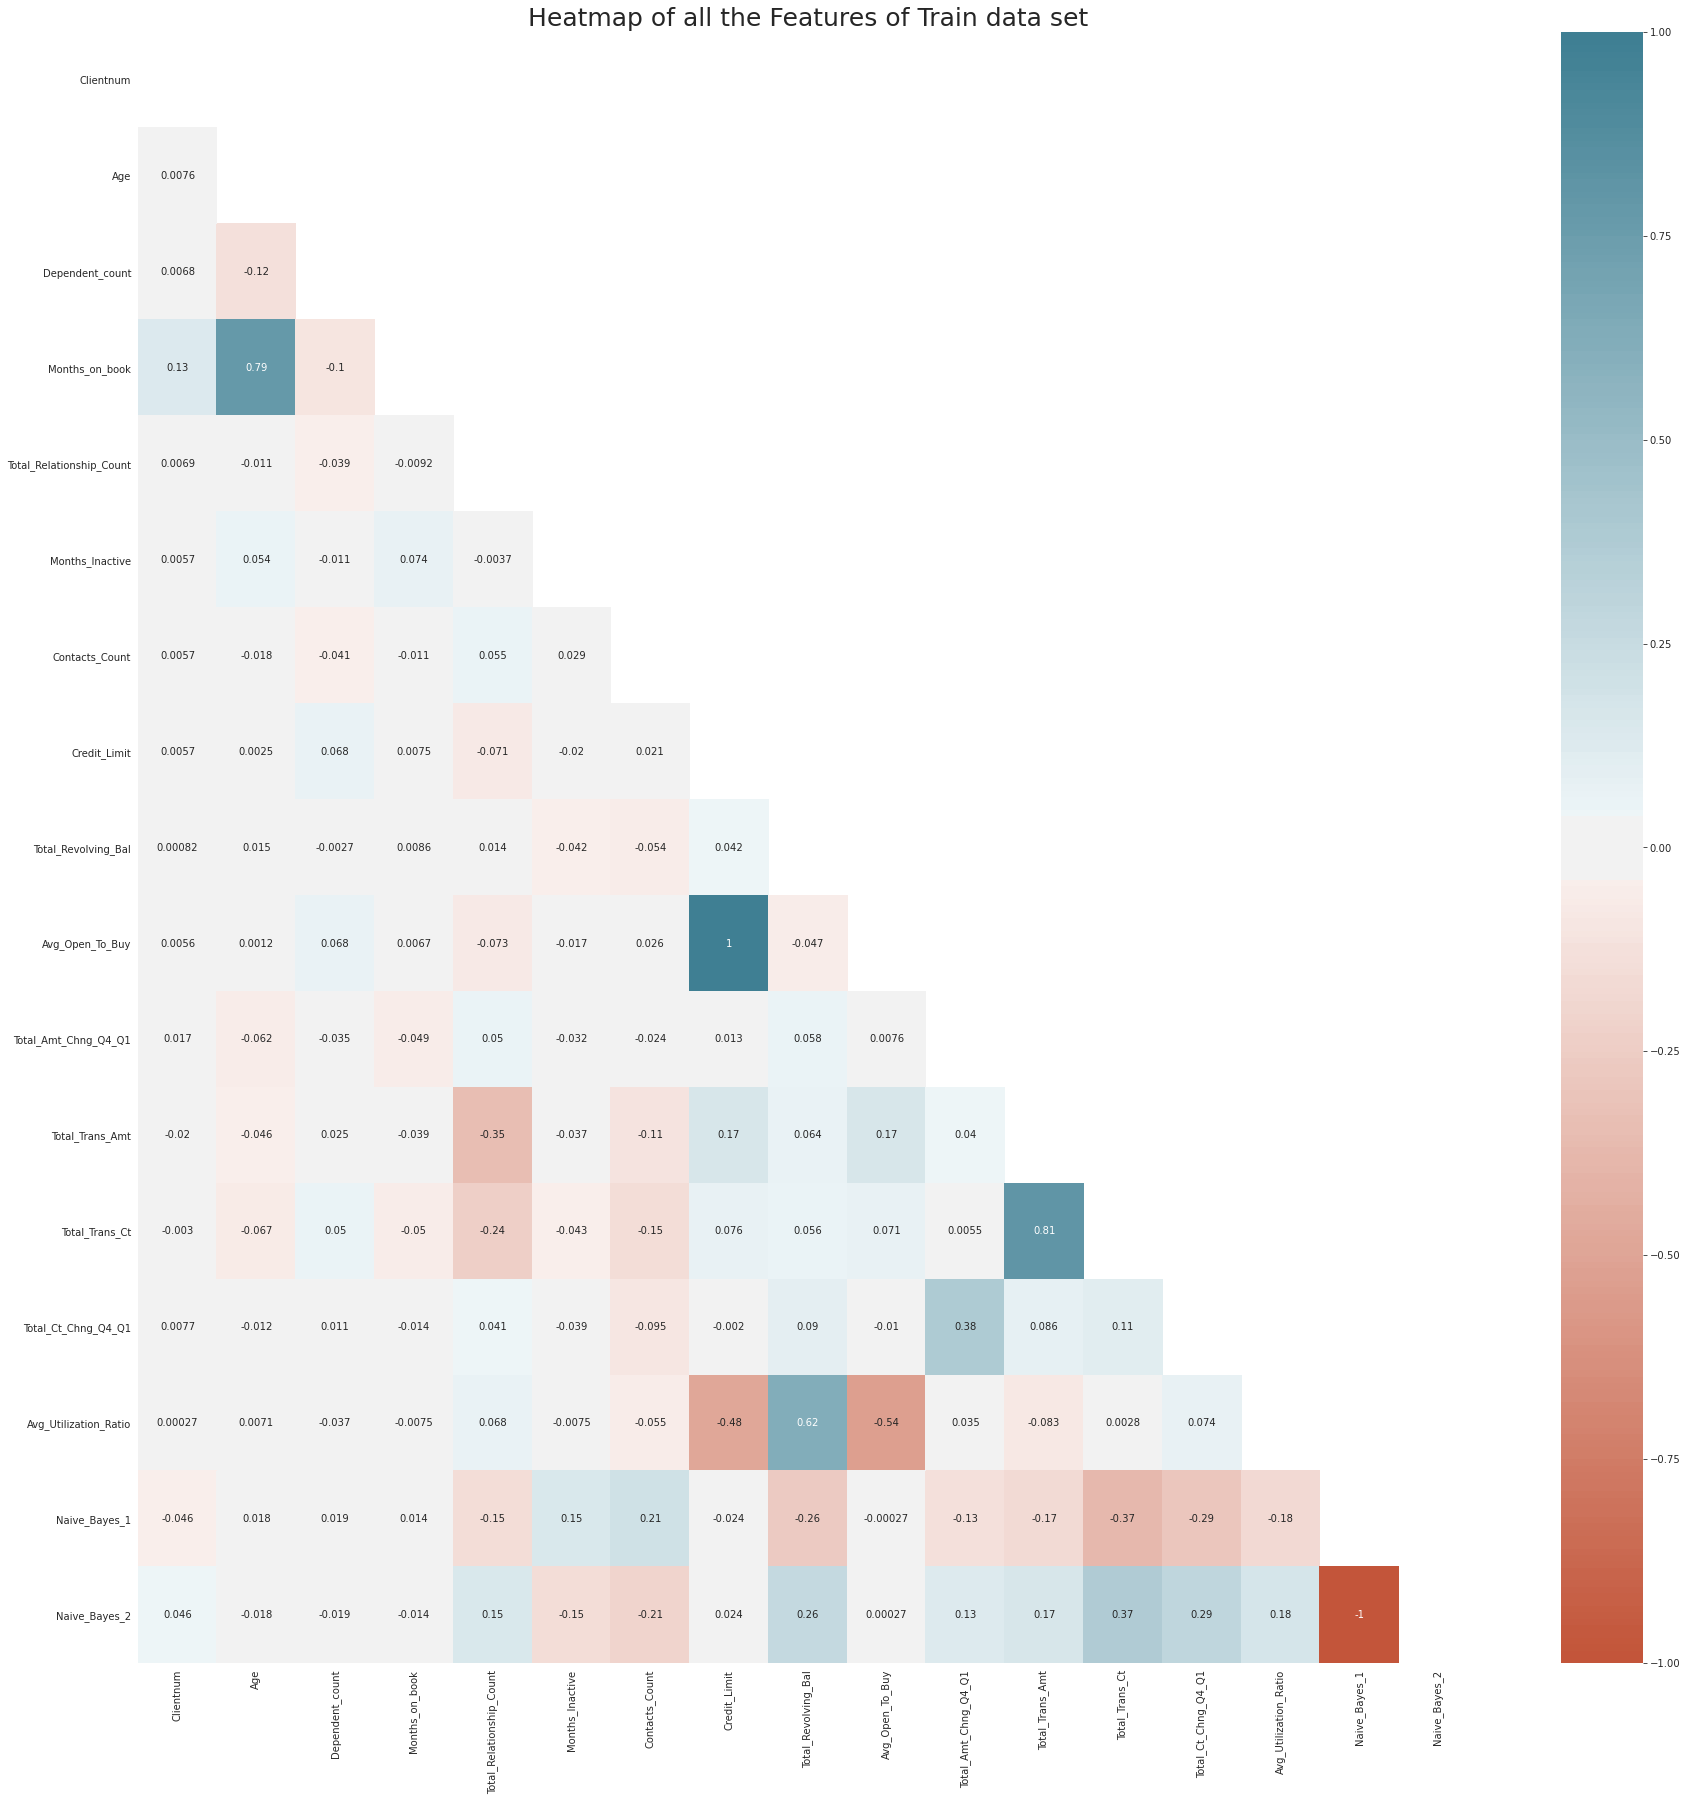

In [10]:
style.use('ggplot')
sns.set_style('whitegrid')
plt.subplots(figsize = (30,30))
## Plotting heatmap. Generate a mask for the upper triangle (taken from seaborn example gallery)
mask = np.zeros_like(data.corr(), dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(data.corr(), cmap=sns.diverging_palette(20, 220, n=200), annot=True, mask=mask, center = 0, );
plt.title("Heatmap of all the Features of Train data set", fontsize = 25);

In [11]:
data.columns

Index(['Clientnum', 'Attrition', 'Age', 'Gender', 'Dependent_count',
       'Education', 'Marital_Status', 'Income', 'Card_Category',
       'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive',
       'Contacts_Count', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_1', 'Naive_Bayes_2'],
      dtype='object')

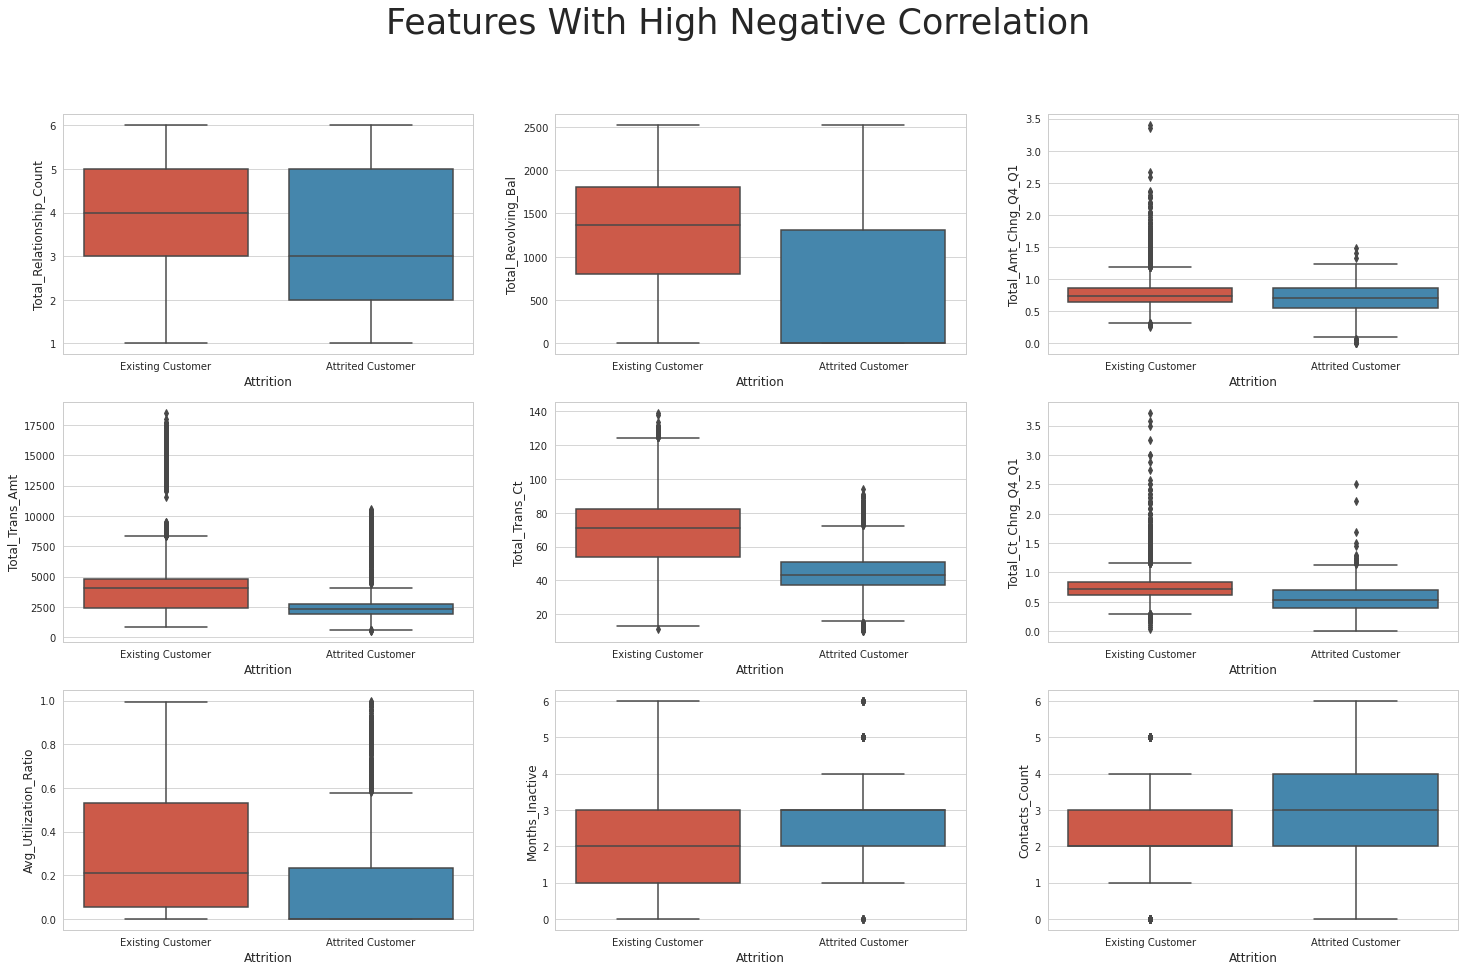

In [12]:
#visualizing the features whigh positive and negative correlation
f, axes = plt.subplots(nrows=3, ncols=3, figsize=(25,15))

f.suptitle('Features With High Negative Correlation', size=35)
sns.boxplot(x="Attrition", y="Total_Relationship_Count", data=data, ax=axes[0,0])
sns.boxplot(x="Attrition", y="Total_Revolving_Bal", data=data, ax=axes[0,1])
sns.boxplot(x="Attrition", y="Total_Amt_Chng_Q4_Q1", data=data, ax=axes[0,2])
sns.boxplot(x="Attrition", y="Total_Trans_Amt", data=data, ax=axes[1,0])
sns.boxplot(x="Attrition", y="Total_Trans_Ct", data=data, ax=axes[1,1])
sns.boxplot(x="Attrition", y="Total_Ct_Chng_Q4_Q1", data=data, ax=axes[1,2])
sns.boxplot(x="Attrition", y="Avg_Utilization_Ratio", data=data, ax=axes[2,0])
sns.boxplot(x="Attrition", y="Months_Inactive", data=data, ax=axes[2,1])
sns.boxplot(x="Attrition", y="Contacts_Count", data=data, ax=axes[2,2])

In [13]:
yprop = 'Age'
xprop = 'Months_Inactive'
h= 'Attrition'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")

In [14]:
yprop = 'Months_on_book'
xprop = 'Dependent_count'
h= 'Attrition'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")

In [15]:
fig = px.box(data, x='Gender',y='Avg_Utilization_Ratio', color='Attrition', notched=True)
fig.update_layout(legend=dict(orientation="h",yanchor="bottom",y=1.02,xanchor="right",x=1))
fig.show()

In [16]:
yprop = 'Total_Amt_Chng_Q4_Q1'
xprop = 'Total_Trans_Amt'
h= 'Attrition'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")

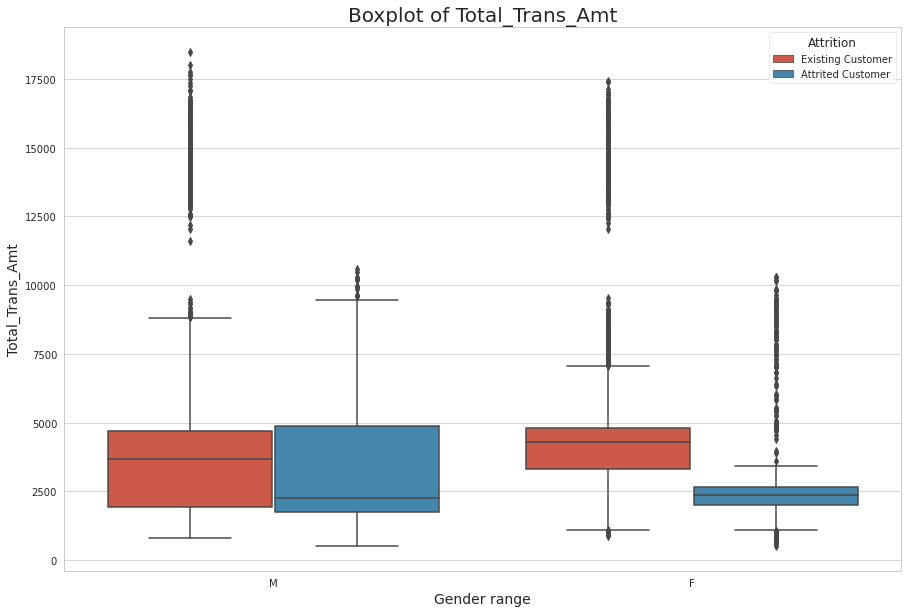

In [17]:
plt.figure(figsize=(15,10))
xprop = 'Gender'
yprop = 'Total_Trans_Amt'
sns.boxplot(data=data, x=xprop, y=yprop, hue='Attrition')
plt.xlabel('{} range'.format(xprop), size=14)
plt.ylabel('{}'.format(yprop), size=14)
plt.title('Boxplot of {}'.format(yprop), size=20)
plt.show()

In [18]:
prop = 'Avg_Utilization_Ratio'
xprop = 'Total_Trans_Ct'
h= 'Attrition'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")

In [19]:
yprop = 'Total_Revolving_Bal'
xprop = 'Credit_Limit'
h= 'Attrition'
px.scatter(data, x=xprop, y=yprop, color=h, marginal_y="violin", marginal_x="box", trendline="ols", template="simple_white")

Overally, it's NOT EASY to conclude something from these illustrations, OR, the analysis is not deep ENOUGH !

But YES, features have not strong correlation with each other.

# Step 3: Converting Categorical Columns to Numeric Columns

Machine learning algorithms work best with numerical data. However, in our dataset, we have some categorical columns. These columns contain data in textual format; we need to convert them to numeric columns.

Firsly, remove the Id column and rearrange the columns.

In [20]:
data = pd.DataFrame(data, columns = ['Age', 'Gender', 'Dependent_count','Education', 'Marital_Status', 
                                     'Income', 'Card_Category','Months_on_book', 'Total_Relationship_Count', 
                                     'Months_Inactive','Contacts_Count', 'Credit_Limit', 'Total_Revolving_Bal',
                                     'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
                                     'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
                                     'Naive_Bayes_1', 'Naive_Bayes_2','Attrition'])

Let's copy the Data and Str Map the NON OBJECT columns.

In [21]:
import copy
df_train=copy.deepcopy(data)
cols=np.array(data.columns[data.dtypes != object])
for i in df_train.columns:
    if i not in cols:
        df_train[i]=df_train[i].map(str)
df_train.drop(columns=cols,inplace=True)

And then, coding the categorical parameters using LabelEncoder.

In [22]:
from sklearn.preprocessing import LabelEncoder
from collections import defaultdict

# build dictionary function
cols=np.array(data.columns[data.dtypes != object])
d = defaultdict(LabelEncoder)

# only for categorical columns apply dictionary by calling fit_transform 
df_train = df_train.apply(lambda x: d[x.name].fit_transform(x))
df_train[cols] = data[cols]

And check the conversion...

In [23]:
df_train.head(2)

,Gender,Education,Marital_Status,Income,Card_Category,Attrition,Age,Dependent_count,Months_on_book,Total_Relationship_Count,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_1,Naive_Bayes_2
0,1,3,1,2,0,1,45,3,39,5,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,0,2,2,4,0,1,49,5,44,6,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994


In [24]:
df_train.columns

Index(['Gender', 'Education', 'Marital_Status', 'Income', 'Card_Category',
       'Attrition', 'Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive', 'Contacts_Count',
       'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy',
       'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_1',
       'Naive_Bayes_2'],
      dtype='object')

# Step 4: Feature Selection

Our data is now ready, and we can train our machine learning model. But first, we need to isolate the variable that we're predicting from the dataset.

In [25]:
df_train.columns

Index(['Gender', 'Education', 'Marital_Status', 'Income', 'Card_Category',
       'Attrition', 'Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive', 'Contacts_Count',
       'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy',
       'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct',
       'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_1',
       'Naive_Bayes_2'],
      dtype='object')

# The following columns/features can be split up in the following groups:       

+ 'Clientium' : Unique identifier for the customer holding the account: we remove this column
+ 'Attrition': Internal event (customer activity) variable - if the account is closed then 1 else 0: this is our target
+ 'Age': Customer's Age in Years.
+ 'Gender': M=Male, F=Female.
+ 'Dependent_count': Number of dependents.
+ 'Education': Educational Qualification of the account holder.
+ 'Marital_Status': Married, Single, Divorced, Unknown.
+ 'Income': Annual Income Category of the account holder
+ 'Card_Category': Type of Card (Blue, Silver, Gold, Platinum).
+ 'Months_on_book': Period of relationship with bank.
+ 'Total_Relationship_Count': Total no. of products held by the customer.
+ 'Months_Inactive': No. of Months in the last 12 months.
+ 'Contacts_Count': No. of Contacts in the last 12 months.
+ 'Credit_Limit': Credit Limit on the Credit Card.
+ 'Total_Revolving_Bal': Total Revolving Balance on the Credit Card.
+ 'Avg_Open_To_Buy': Open to Buy Credit Line (Average of last 12 months
+ 'Total_Amt_Chng_Q4_Q1': Change in Transaction Amount (Q4 over Q1).
+ 'Total_Trans_Amt': Total Transaction Amount (Last 12 months).
+ 'Total_Trans_Ct': Total Transaction Count (Last 12 months).
+ 'Total_Ct_Chng_Q4_Q1': Change in Transaction Count (Q4 over Q1).
+ 'Avg_Utilization_Ratio': Average Card Utilization Ratio.

AS NOTICED:

+ Naive_Bayes: It was mentioned that all columns containing the "N.B."-tag should be disregarded: we remove these 2 columns

In [26]:
df_train = pd.DataFrame(df_train, columns = ['Age', 'Gender', 'Dependent_count','Education', 'Marital_Status', 'Income', 
                                             'Card_Category','Months_on_book', 'Total_Relationship_Count', 'Months_Inactive',
                                             'Contacts_Count', 'Credit_Limit', 'Total_Revolving_Bal','Avg_Open_To_Buy', 
                                             'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt','Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
                                             'Avg_Utilization_Ratio','Attrition'])

In [27]:
len(df_train.columns)

20

In [28]:
# Find most important features relative to target Price
print("Find most important features relative to Attrition-target")
corr = df_train.corr()
corr.sort_values(["Attrition"], ascending = False, inplace = True)
print(corr.Attrition)

Find most important features relative to Attrition-target
Attrition                   1.000000
Total_Trans_Ct              0.371403
Total_Ct_Chng_Q4_Q1         0.290054
Total_Revolving_Bal         0.263053
Avg_Utilization_Ratio       0.178410
Total_Trans_Amt             0.168598
Total_Relationship_Count    0.150005
Total_Amt_Chng_Q4_Q1        0.131063
Gender                      0.037272
Credit_Limit                0.023873
Card_Category               0.006038
Avg_Open_To_Buy             0.000285
Education                  -0.005551
Months_on_book             -0.013687
Income                     -0.017584
Age                        -0.018203
Marital_Status             -0.018597
Dependent_count            -0.018991
Months_Inactive            -0.152449
Contacts_Count             -0.204491
Name: Attrition, dtype: float64


In [29]:
df_train.describe()

,Age,Gender,Dependent_count,Education,Marital_Status,Income,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive,Contacts_Count,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Attrition
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,0.470919,2.346203,3.096574,1.463415,2.863928,0.179816,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.839340
std,8.016814,0.499178,1.298908,1.834812,0.737808,1.504700,0.693039,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.367235
min,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000000
25%,41.000000,0.000000,1.000000,2.000000,1.000000,2.000000,0.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,1.000000
50%,46.000000,0.000000,2.000000,3.000000,1.000000,3.000000,0.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,1.000000
75%,52.000000,1.000000,3.000000,5.000000,2.000000,4.000000,0.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,1.000000
max,73.000000,1.000000,5.000000,6.000000,3.000000,5.000000,3.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,1.000000


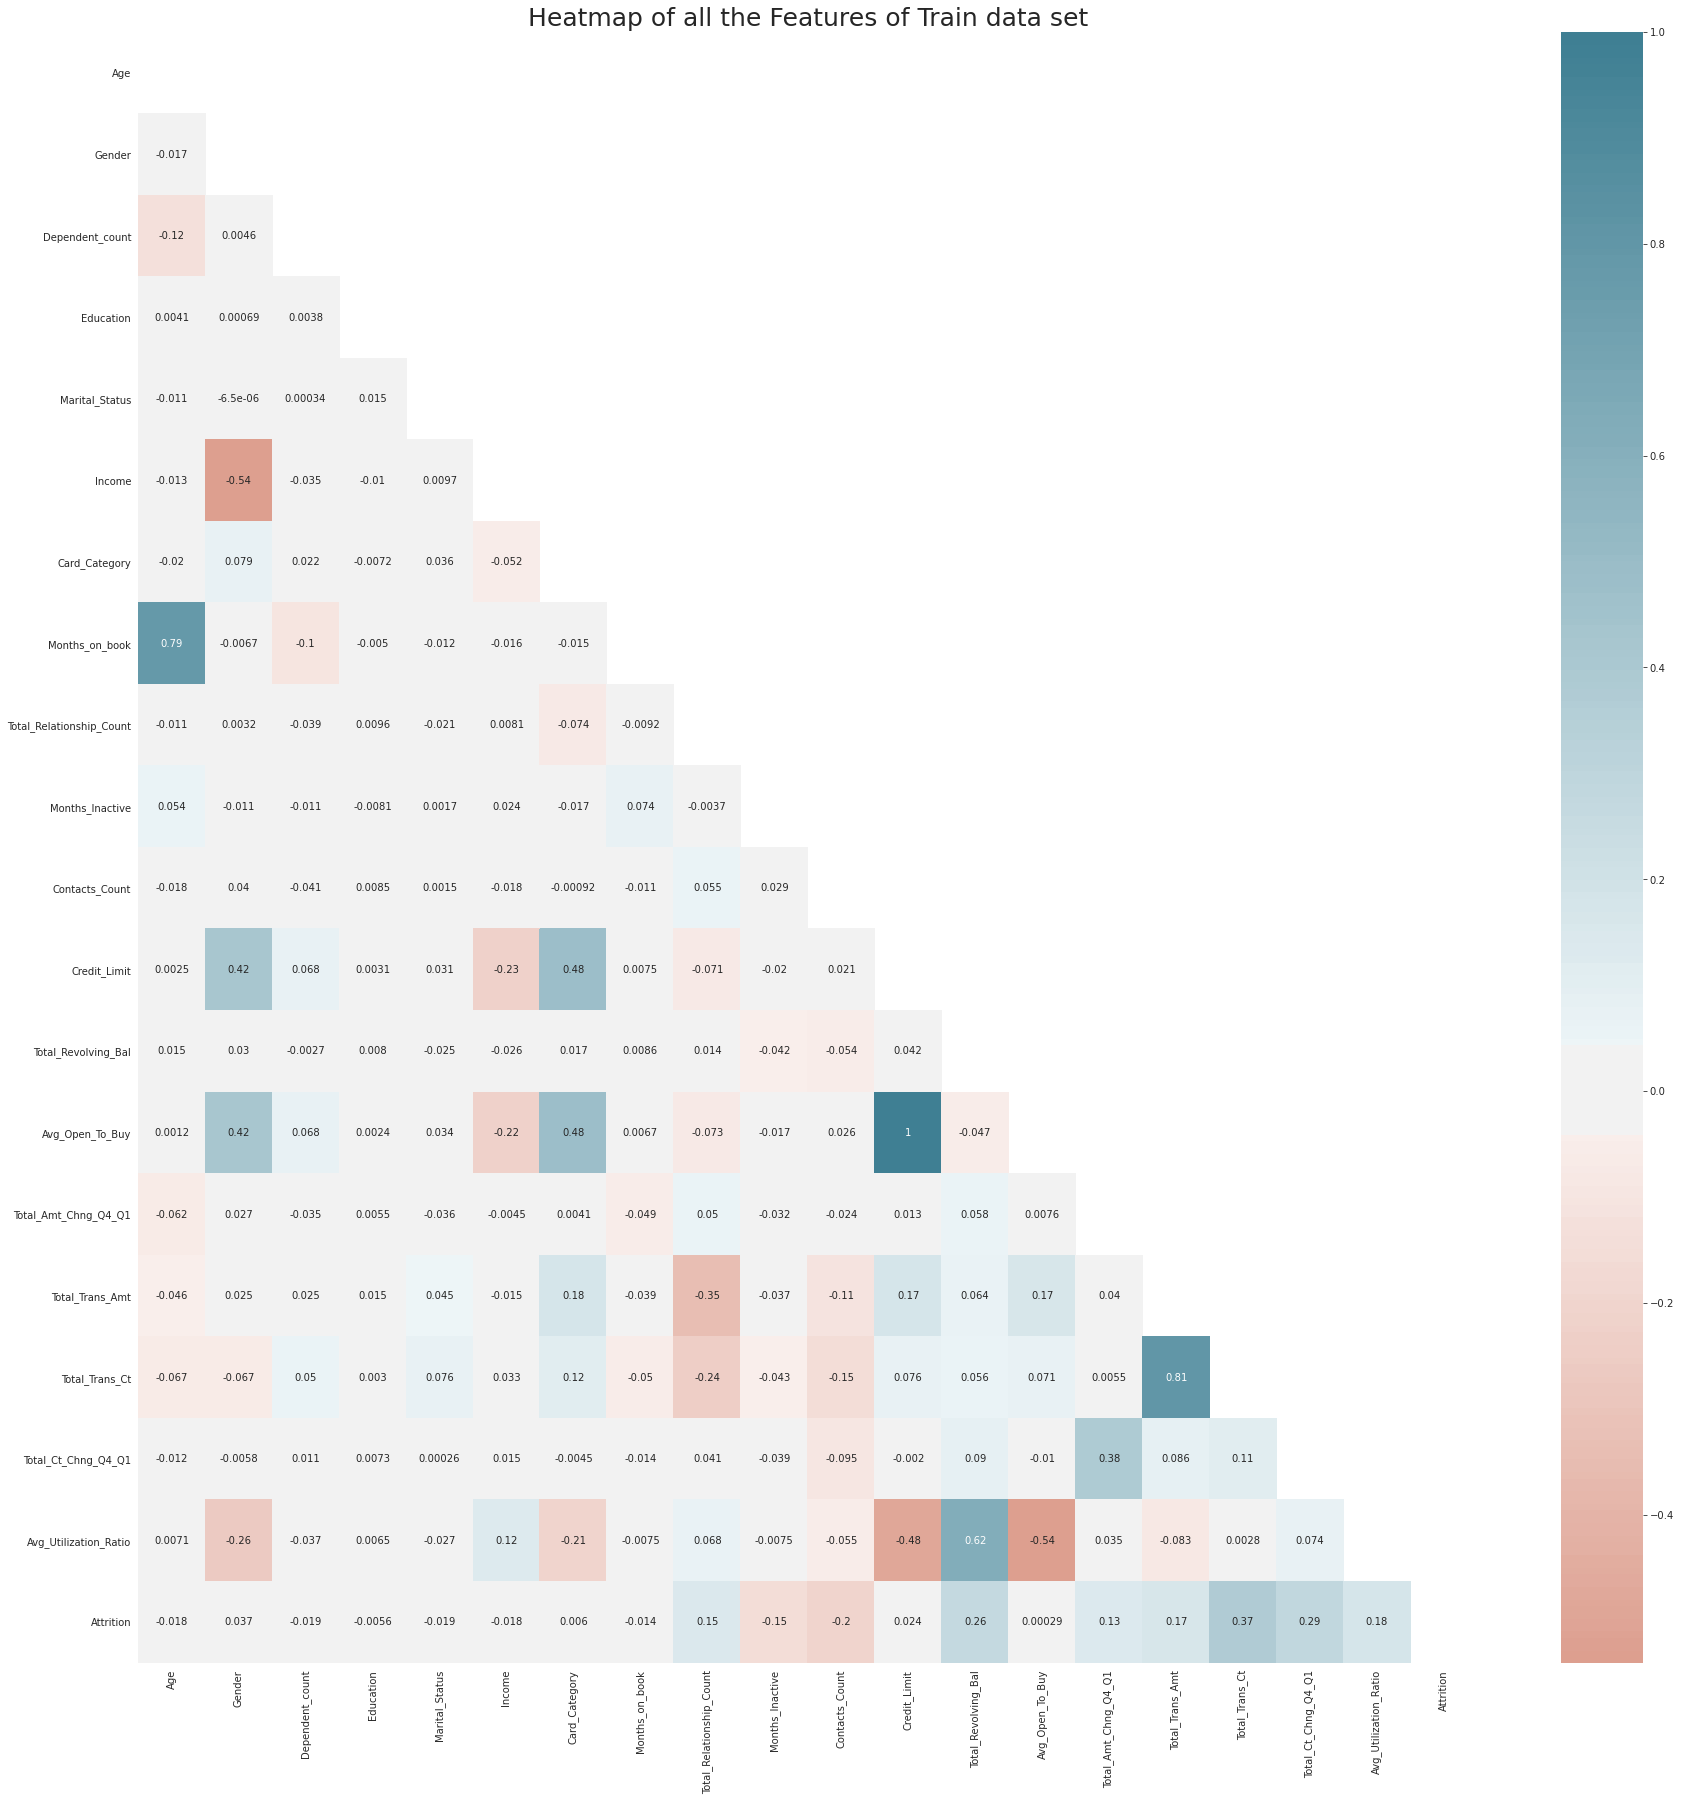

In [30]:
style.use('ggplot')
sns.set_style('whitegrid')
plt.subplots(figsize = (30,30))
## Plotting heatmap. Generate a mask for the upper triangle (taken from seaborn example gallery)
mask = np.zeros_like(df_train.corr(), dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(df_train.corr(), cmap=sns.diverging_palette(20, 220, n=200), annot=True, mask=mask, center = 0, );
plt.title("Heatmap of all the Features of Train data set", fontsize = 25);

OK, let's remove some columns with very low correlation: "Avg_Open_To_Buy"

In [31]:
features = ['Age', 'Gender', 'Dependent_count', 'Education','Marital_Status', 'Income', 'Card_Category','Months_on_book',
            'Total_Relationship_Count','Months_Inactive','Contacts_Count', 'Credit_Limit', 'Total_Revolving_Bal','Total_Amt_Chng_Q4_Q1', 
            'Total_Trans_Amt','Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio','Attrition']
df_train = pd.DataFrame(df_train, columns = features)

In [32]:
df_train.columns

Index(['Age', 'Gender', 'Dependent_count', 'Education', 'Marital_Status',
       'Income', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count',
       'Months_Inactive', 'Contacts_Count', 'Credit_Limit',
       'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Attrition'],
      dtype='object')

# Step 5: Churn Prediction Model

In this section we present several regression models for the churn prediction, and compare their relative performances in terms of standard metrics such as precision, recall, specificity, and AUC. These performances also allow us to evaluate the effectiveness of the outlier removal, undersampling and ensemble techniques.

Now, import ML Librairie pakages

In [33]:
from collections import Counter
from imblearn.over_sampling import ADASYN
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from numpy import where
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble.gradient_boosting import GradientBoostingClassifier
from sklearn.ensemble.forest import ExtraTreesClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import plot_confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBClassifier

# A. Sampling

As observed, the number of churners is usually much smaller than the number of non-churners, leading to an imbalanced training set. This issue was also present in our analysis, we obsed the Churners rate is upto 16%, which might be NOT MUCH imbalanced. In particular, the most effective method was undersampling, which outperformed the sampling techniques that replicates the rare class, since the latter ones resulted in over-fitting the rare class, thus degrading the model performance significantly. In particular, the undersampling technique significantly improved the results only if combined with the outlier removal. The best proportion between classes was chosen so to optimize the classifier performance on the test set.

We define the Data for Input purpose as following:

In [34]:
def Definedata():
    # define dataset
    X=df_train.drop(columns=['Attrition']).values
    y=df_train['Attrition'].values
    return X, y

Here, X is our feature set; it contains all the columns except the one that we have to predict (Exited). The label set, y, contains only the Exited column. So we can later evaluate the performance of our machine learning model, let's also divide the data into a training and test set. The training set contains the data that will be used to train our machine learning model. The test set will be used to evaluate how good our model is. 

# We'll use 33% of the data for the test set and the remaining 67% for the training set.

In [35]:
from sklearn.metrics import classification_report
def Models_NO(models, graph):
    
    model = models
    X, y = Definedata()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 25)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_total = model.predict(X)
    
    if graph:
        train_matrix = pd.crosstab(y_train, model.predict(X_train), rownames=['Actual'], colnames=['Predicted'])    
        test_matrix = pd.crosstab(y_test, model.predict(X_test), rownames=['Actual'], colnames=['Predicted'])
        matrix = pd.crosstab(y, model.predict(X), rownames=['Actual'], colnames=['Predicted'])
    
        f,(ax1,ax2,ax3) = plt.subplots(1,3,sharey=True, figsize=(15, 2))
    
        g1 = sns.heatmap(train_matrix, annot=True, fmt=".1f", cbar=False,annot_kws={"size": 18},ax=ax1)
        g1.set_title("{}/train set".format(model))
        g1.set_ylabel('Total Churn = {}'.format(1- y_train.sum()), fontsize=14, rotation=90)
        g1.set_xlabel('Accuracy for TrainSet: {}'.format(accuracy_score(model.predict(X_train), y_train)))
        g1.set_xticklabels(['Churn','Not Churn'],fontsize=12)

        g2 = sns.heatmap(test_matrix, annot=True, fmt=".1f",cbar=False,annot_kws={"size": 18},ax=ax2)
        g2.set_title("{}/test set".format(model))
        g2.set_ylabel('Total Churn = {}'.format(1- y_test.sum()), fontsize=14, rotation=90)
        g2.set_xlabel('Accuracy for TestSet: {}'.format(accuracy_score(y_pred, y_test)))
        g2.set_xticklabels(['Churn','Not Churn'],fontsize=12)

        g3 = sns.heatmap(matrix, annot=True, fmt=".1f",cbar=False,annot_kws={"size": 18},ax=ax3)
        g3.set_title("{}/total set".format(model))
        g3.set_ylabel('Total Churn = {}'.format(1- y.sum()), fontsize=14, rotation=90)
        g3.set_xlabel('Accuracy for TotalSet: {}'.format(accuracy_score(y_total, y)))
        g3.set_xticklabels(['Churn','Not Churn'],fontsize=12)
    
        plt.show()
        print ("")
        print ("Classification Report: ")
        print (classification_report(y, y_total))
    else:
        print("\t\tError Table")
        print('Mean Absolute Error      : ', metrics.mean_absolute_error(y_test, (y_pred)))
        print('Mean Squared  Error      : ', metrics.mean_squared_error(y_test, (y_pred) ))
        print('Root Mean Squared  Error : ', np.sqrt(metrics.mean_squared_error(y_test, (y_pred) )))
        print('Accuracy on Traing set   : ', model.score(X_train,y_train))
        print('Accuracy on Testing set  : ', model.score(X_test,y_test))
        print('AUC score                :', roc_auc_score(y, y_total)*100,'%')        
    return y_total, y

# B. Machine Learning Algorithm Training

Now, we'll use a machine learning algorithm that will identify patterns or trends in the training data. This step is known as algorithm training. We'll feed the features and correct output to the algorithm; based on that data, the algorithm will learn to find associations between the features and outputs. After training the algorithm, you'll be able to use it to make predictions on new data.

There are several machine learning algorithms that can be used to make such predictions. In this work, we'll try some ALGORITHMS to select one of the most powerful algorithms for classification problems.

To train this algorithm, we call the fit method and pass in the feature set (X) and the corresponding label set (y). You can then use the predict method to make predictions on the test set. Look at the following script:

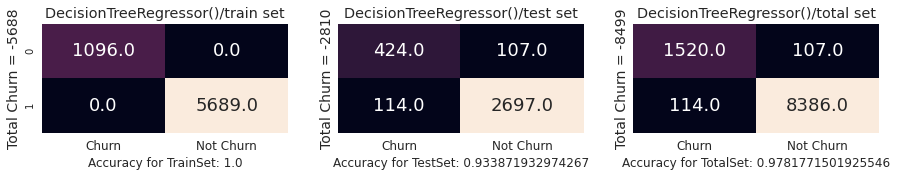


Classification Report: 
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1627
           1       0.99      0.99      0.99      8500

    accuracy                           0.98     10127
   macro avg       0.96      0.96      0.96     10127
weighted avg       0.98      0.98      0.98     10127



In [36]:
y_predict, y_test = Models_NO(DecisionTreeRegressor(), True)

We could confirm that the data is IMBALANCED and the regressor can not handle this data set. Let start the second step.

		Error Table
Mean Absolute Error      :  0.06253740275284261
Mean Squared  Error      :  0.06253740275284261
Root Mean Squared  Error :  0.25007479431730545
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.5320522483303085
AUC score                : 96.08689034310713 %


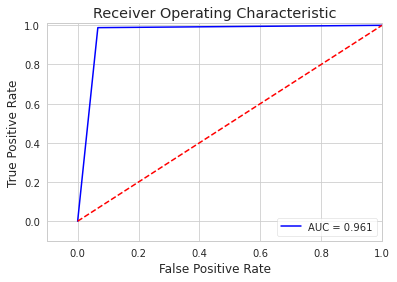

In [37]:
from sklearn.metrics import confusion_matrix,auc,roc_curve

y_predicted, y_actual = Models_NO(DecisionTreeRegressor(), False)
fpr, tpr, thresholds = roc_curve(y_actual, y_predicted)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',label='AUC = %0.3f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.1,1.0])
plt.ylim([-0.1,1.01])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

# C. SMOTE sampling

In [38]:
def SMOTE():
    # borderline-SMOTE for imbalanced dataset
    from collections import Counter
    from sklearn.model_selection import train_test_split
    from sklearn.datasets import make_classification
    from imblearn.over_sampling import SMOTE
    from matplotlib import pyplot
    from numpy import where
    
    X, y = Definedata()

# summarize class distribution
    counter = Counter(y)
    print(counter)
# transform the dataset
    smt = SMOTE(random_state=0)
    X, y = smt.fit_sample(X, y) 
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=2)
# summarize the new class distribution
    counter = Counter(y)
    print(counter)
# scatter plot of examples by class label
    for label, _ in counter.items():
        row_ix = where(y == label)[0]
        pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
    pyplot.legend()
    pyplot.show()
    return X_train, X_test, y_train, y_test

In [39]:
def ADASYN():
    from collections import Counter
    from sklearn.model_selection import train_test_split
    from imblearn.over_sampling import ADASYN
    from matplotlib import pyplot
    from numpy import where

    X, y = Definedata()

# summarize class distribution
    counter = Counter(y)
    print(counter)
# transform the dataset
    X, y = ADASYN().fit_resample(X, y)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=2)
# summarize the new class distribution
    counter = Counter(y)
    print(counter)
# scatter plot of examples by class label
    for label, _ in counter.items():
        row_ix = where(y == label)[0]
        pyplot.scatter(X[row_ix, 0], X[row_ix, 1], label=str(label))
    pyplot.legend()
    pyplot.show()
    return X_train, X_test, y_train, y_test

Counter({1: 8500, 0: 1627})
Counter({1: 8500, 0: 8500})


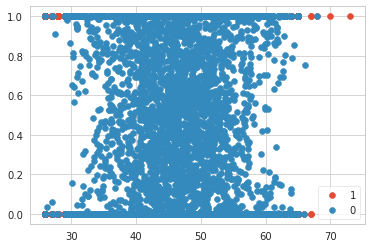

CPU times: user 658 ms, sys: 6.99 ms, total: 665 ms
Wall time: 666 ms
Counter({1: 8500, 0: 1627})
Counter({0: 8771, 1: 8500})


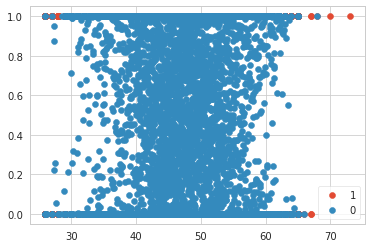

CPU times: user 707 ms, sys: 6.77 ms, total: 713 ms
Wall time: 712 ms


In [40]:
%time X_train1, X_test1, y_train1, y_test1 = SMOTE()
%time X_train4, X_test4, y_train4, y_test4 = ADASYN()

In [41]:
def Models(models, X_train, X_test, y_train, y_test, title, graph):
    model = models
    model.fit(X_train,y_train)
    
    X, y = Definedata()
    train_matrix = pd.crosstab(y_train, model.predict(X_train), rownames=['Actual'], colnames=['Predicted'])    
    test_matrix = pd.crosstab(y_test, model.predict(X_test), rownames=['Actual'], colnames=['Predicted'])
    matrix = pd.crosstab(y, model.predict(X), rownames=['Actual'], colnames=['Predicted'])
    
    if graph:
        f,(ax1,ax2,ax3) = plt.subplots(1,3,sharey=True, figsize=(15, 2))
    
        g1 = sns.heatmap(train_matrix, annot=True, fmt=".1f", cbar=False,annot_kws={"size": 18},ax=ax1)
        g1.set_title(title)
        g1.set_ylabel('Total Churn = {}'.format(y_train.sum()), fontsize=14, rotation=90)
        g1.set_xlabel('Accuracy score (TrainSet): {}'.format(accuracy_score(model.predict(X_train), y_train)))
        g1.set_xticklabels(['Churn','Not Churn'],fontsize=12)

        g2 = sns.heatmap(test_matrix, annot=True, fmt=".1f",cbar=False,annot_kws={"size": 18},ax=ax2)
        g2.set_title(title)
        g2.set_ylabel('Total Churn = {}'.format(y_test.sum()), fontsize=14, rotation=90)
        g2.set_xlabel('Accuracy score (TestSet): {}'.format(accuracy_score(model.predict(X_test), y_test)))
        g2.set_xticklabels(['Churn','Not Churn'],fontsize=12)

        g3 = sns.heatmap(matrix, annot=True, fmt=".1f",cbar=False,annot_kws={"size": 18},ax=ax3)
        g3.set_title(title)
        g3.set_ylabel('Total Churn = {}'.format(y.sum()), fontsize=14, rotation=90)
        g3.set_xlabel('Accuracy score (Total): {}'.format(accuracy_score(model.predict(X), y)))
        g3.set_xticklabels(['Churn','Not Churn'],fontsize=12)

        plt.show()

    print("\t\tError Table")
    print('Accuracy on Traing set   : ', model.score(X_train,y_train))
    print('Accuracy on Testing set  : ', model.score(X_test,y_test))
    print('Overall Accuracy_Score   :',accuracy_score(y, model.predict(X))*100,'%')
    print('Recall ratio             :',metrics.recall_score(y, model.predict(X))*100,'%')
    print('AUC score                :', roc_auc_score(y, model.predict(X))*100,'%')

    return y, model.predict(X)

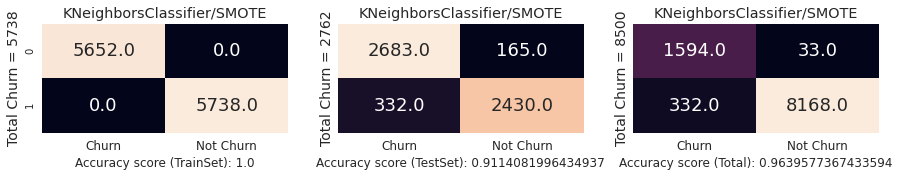

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9114081996434937
Overall Accuracy_Score   : 96.39577367433594 %
Recall ratio             : 96.09411764705882 %
AUC score                : 97.03292237608011 %
CPU times: user 5.16 s, sys: 22.7 ms, total: 5.19 s
Wall time: 5.17 s


In [42]:
title = 'KNeighborsClassifier/SMOTE'
%time y_actual,y_predicted = Models(KNeighborsClassifier(n_neighbors=1),X_train1, X_test1, y_train1, y_test1, title, True)

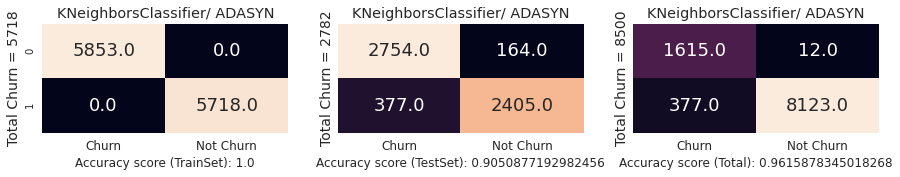

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9050877192982456
Overall Accuracy_Score   : 96.15878345018268 %
Recall ratio             : 95.56470588235294 %
AUC score                : 97.41357605119492 %
CPU times: user 5.16 s, sys: 21.7 ms, total: 5.18 s
Wall time: 5.16 s


(array([1, 1, 1, ..., 0, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]))

In [43]:
title = 'KNeighborsClassifier/ ADASYN'
%time Models(KNeighborsClassifier(n_neighbors=1),X_train4, X_test4, y_train4, y_test4, title, True)

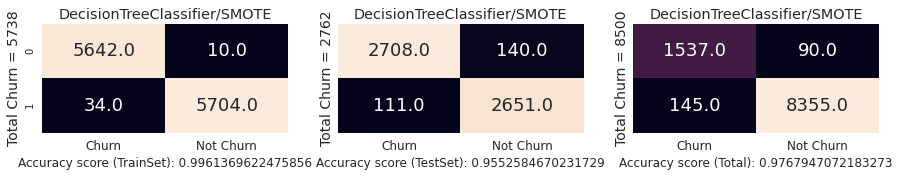

		Error Table
Accuracy on Traing set   :  0.9961369622475856
Accuracy on Testing set  :  0.9552584670231729
Overall Accuracy_Score   : 97.67947072183273 %
Recall ratio             : 98.29411764705883 %
AUC score                : 96.3812321486677 %
CPU times: user 666 ms, sys: 9.05 ms, total: 675 ms
Wall time: 672 ms


In [44]:
title = 'DecisionTreeClassifier/SMOTE'
%time y_actual,y_predicted = Models(DecisionTreeClassifier(max_depth=14),X_train1, X_test1, y_train1, y_test1, title, True)

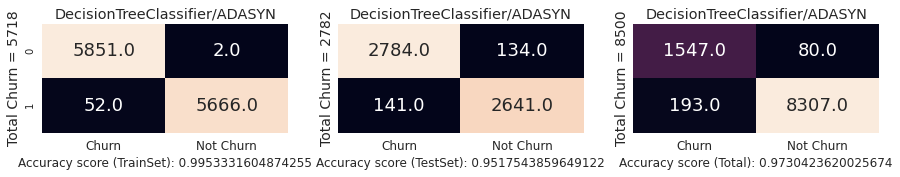

		Error Table
Accuracy on Traing set   :  0.9953331604874255
Accuracy on Testing set  :  0.9517543859649122
Overall Accuracy_Score   : 97.30423620025674 %
Recall ratio             : 97.72941176470589 %
AUC score                : 96.40619328247587 %
CPU times: user 638 ms, sys: 11 ms, total: 649 ms
Wall time: 644 ms


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [45]:
title = 'DecisionTreeClassifier/ADASYN'
%time Models(DecisionTreeClassifier(max_depth=14),X_train4, X_test4, y_train4, y_test4, title, True)

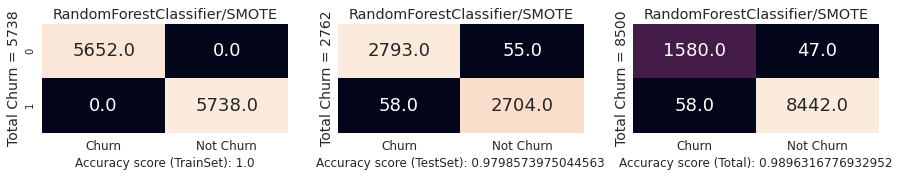

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9798573975044563
Overall Accuracy_Score   : 98.96316776932952 %
Recall ratio             : 99.31764705882354 %
AUC score                : 98.21444737698398 %
CPU times: user 4.07 s, sys: 15.6 ms, total: 4.09 s
Wall time: 4.08 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [46]:
title = 'RandomForestClassifier/SMOTE'
%time Models(RandomForestClassifier(),X_train1, X_test1, y_train1, y_test1, title, True)

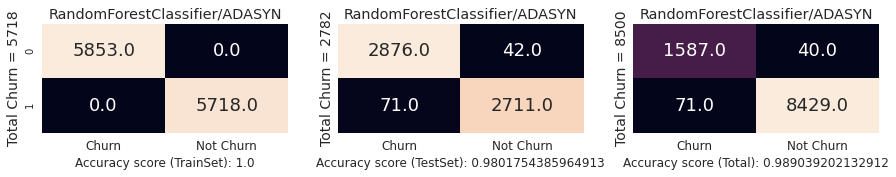

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9801754385964913
Overall Accuracy_Score   : 98.9039202132912 %
Recall ratio             : 99.16470588235295 %
AUC score                : 98.35309664123794 %
CPU times: user 4.22 s, sys: 16.7 ms, total: 4.24 s
Wall time: 4.23 s


In [47]:
title = 'RandomForestClassifier/ADASYN'
%time y_actual,y_predicted = Models(RandomForestClassifier(),X_train4, X_test4, y_train4, y_test4, title, True)

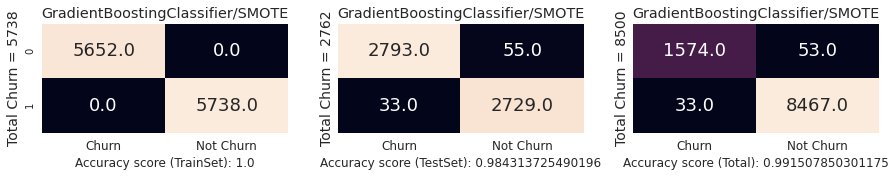

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.984313725490196
Overall Accuracy_Score   : 99.1507850301175 %
Recall ratio             : 99.61176470588235 %
AUC score                : 98.1771177555226 %
CPU times: user 26.3 s, sys: 9.43 ms, total: 26.3 s
Wall time: 26.3 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [48]:
title = 'GradientBoostingClassifier/SMOTE'
%time Models(GradientBoostingClassifier(n_estimators=1500, learning_rate=1, max_features=10, max_depth=2, random_state=0),X_train1, X_test1, y_train1, y_test1, title, True)

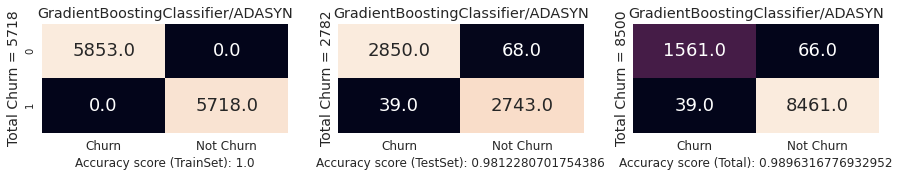

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9812280701754386
Overall Accuracy_Score   : 98.96316776932952 %
Recall ratio             : 99.54117647058823 %
AUC score                : 97.74231534039554 %
CPU times: user 3.66 s, sys: 11.9 ms, total: 3.67 s
Wall time: 3.67 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [49]:
title = 'GradientBoostingClassifier/ADASYN'
%time Models(GradientBoostingClassifier(n_estimators=500, learning_rate=1, max_features=2, max_depth=2, random_state=0),X_train4, X_test4, y_train4, y_test4, title, True)

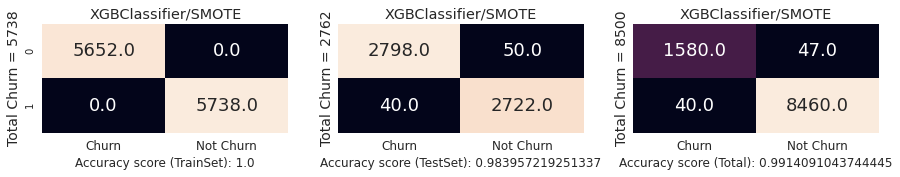

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.983957219251337
Overall Accuracy_Score   : 99.14091043744445 %
Recall ratio             : 99.52941176470588 %
AUC score                : 98.32032972992516 %
CPU times: user 9.17 s, sys: 169 ms, total: 9.34 s
Wall time: 2.65 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [50]:
title = 'XGBClassifier/SMOTE'
%time Models(XGBClassifier(colsample_bytree=0.9, learning_rate=0.2, max_depth=7),X_train1, X_test1, y_train1, y_test1, title, True)

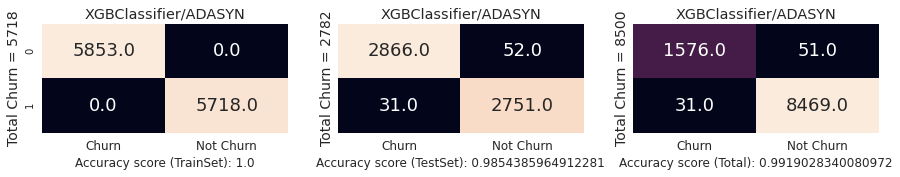

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9854385964912281
Overall Accuracy_Score   : 99.19028340080972 %
Recall ratio             : 99.63529411764705 %
AUC score                : 98.25034527640189 %
CPU times: user 7.55 s, sys: 92.8 ms, total: 7.65 s
Wall time: 1.94 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [51]:
title = 'XGBClassifier/ADASYN'
%time Models(XGBClassifier(colsample_bytree=0.9, learning_rate=0.2, max_depth=7),X_train4, X_test4, y_train4, y_test4, title, True)

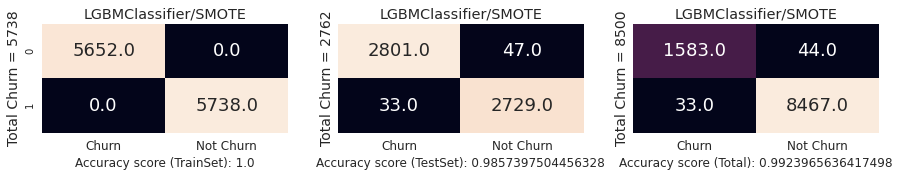

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9857397504456328
Overall Accuracy_Score   : 99.23965636417498 %
Recall ratio             : 99.61176470588235 %
AUC score                : 98.4537004230088 %
CPU times: user 27 s, sys: 9.37 s, total: 36.3 s
Wall time: 9.28 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [52]:
title = 'LGBMClassifier/SMOTE'
%time Models(LGBMClassifier(max_depth=-1, random_state=20, silent=True, metric='None', n_jobs=5, n_estimators=1000),X_train1, X_test1, y_train1, y_test1, title, True)

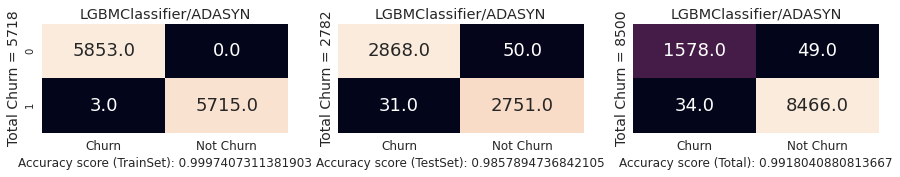

		Error Table
Accuracy on Traing set   :  0.9997407311381903
Accuracy on Testing set  :  0.9857894736842105
Overall Accuracy_Score   : 99.18040880813666 %
Recall ratio             : 99.6 %
AUC score                : 98.29416103257529 %
CPU times: user 4.59 s, sys: 2.62 s, total: 7.22 s
Wall time: 1.93 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [53]:
title = 'LGBMClassifier/ADASYN'
%time Models(LGBMClassifier(),X_train4, X_test4, y_train4, y_test4, title, True)

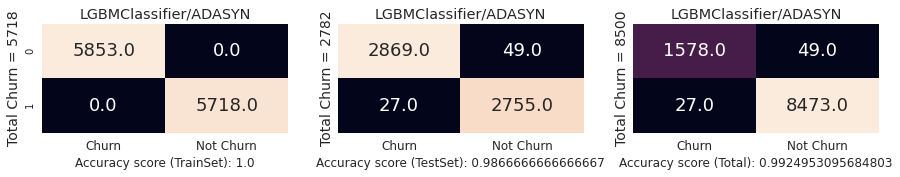

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9866666666666667
Overall Accuracy_Score   : 99.24953095684803 %
Recall ratio             : 99.68235294117646 %
AUC score                : 98.33533750316352 %
CPU times: user 45.4 s, sys: 22.3 s, total: 1min 7s
Wall time: 17.2 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [54]:
title = 'LGBMClassifier/ADASYN'
%time Models(LGBMClassifier(max_depth=-1, random_state=310, silent=True, metric='None', n_jobs=15, n_estimators=2000),X_train4, X_test4, y_train4, y_test4, title, True)

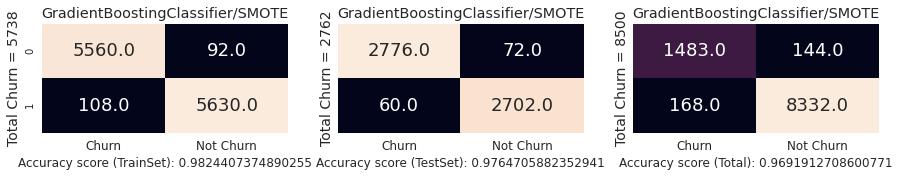

		Error Table
Accuracy on Traing set   :  0.9824407374890255
Accuracy on Testing set  :  0.9764705882352941
Overall Accuracy_Score   : 96.9191270860077 %
Recall ratio             : 98.02352941176471 %
AUC score                : 94.58644202610363 %
CPU times: user 4.59 s, sys: 10.9 ms, total: 4.6 s
Wall time: 4.61 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [55]:
title = 'GradientBoostingClassifier/SMOTE'
%time Models(GradientBoostingClassifier(),X_train1, X_test1, y_train1, y_test1, title, True)

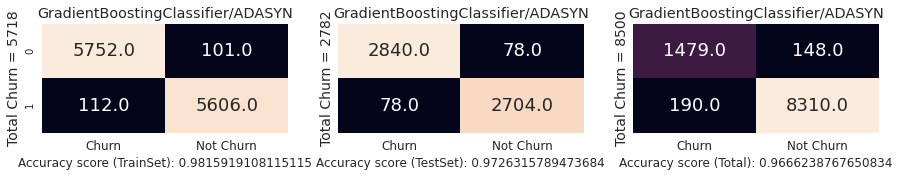

		Error Table
Accuracy on Traing set   :  0.9815919108115115
Accuracy on Testing set  :  0.9726315789473684
Overall Accuracy_Score   : 96.66238767650835 %
Recall ratio             : 97.76470588235294 %
AUC score                : 94.33410463140389 %
CPU times: user 4.79 s, sys: 11.9 ms, total: 4.8 s
Wall time: 4.8 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [56]:
title = 'GradientBoostingClassifier/ADASYN'
%time Models(GradientBoostingClassifier(),X_train4, X_test4, y_train4, y_test4, title, True)

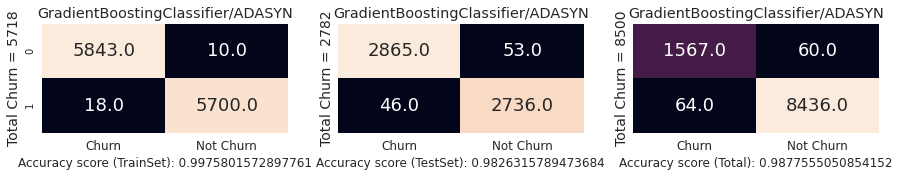

		Error Table
Accuracy on Traing set   :  0.9975801572897761
Accuracy on Testing set  :  0.9826315789473684
Overall Accuracy_Score   : 98.77555050854153 %
Recall ratio             : 99.24705882352941 %
AUC score                : 97.7796449618569 %
CPU times: user 1min 16s, sys: 41.8 ms, total: 1min 16s
Wall time: 1min 16s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [57]:
title = 'GradientBoostingClassifier/ADASYN'
%time Models(GradientBoostingClassifier(learning_rate=0.005, n_estimators=1500,max_depth=20, min_samples_split=300, min_samples_leaf=60, subsample=0.85, random_state=10, max_features=7,warm_start=True),X_train4, X_test4, y_train4, y_test4, title, True)

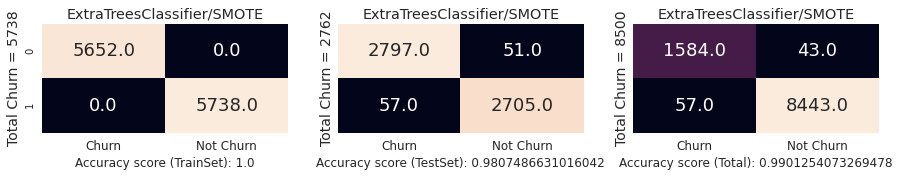

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9807486631016042
Overall Accuracy_Score   : 99.01254073269477 %
Recall ratio             : 99.32941176470588 %
AUC score                : 98.34325535991903 %
CPU times: user 3.41 s, sys: 25.1 ms, total: 3.43 s
Wall time: 3.43 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 1]))

In [58]:
title = 'ExtraTreesClassifier/SMOTE'
%time Models(ExtraTreesClassifier(),X_train1, X_test1, y_train1, y_test1, title, True)

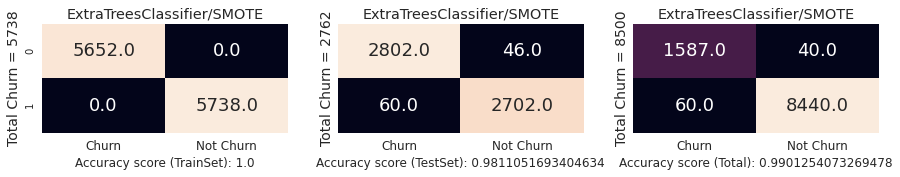

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9811051693404634
Overall Accuracy_Score   : 99.01254073269477 %
Recall ratio             : 99.29411764705883 %
AUC score                : 98.41780252359088 %
CPU times: user 3.35 s, sys: 21.4 ms, total: 3.37 s
Wall time: 3.36 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 1]))

In [59]:
title = 'ExtraTreesClassifier/SMOTE'
%time Models(ExtraTreesClassifier(),X_train1, X_test1, y_train1, y_test1, title, True)

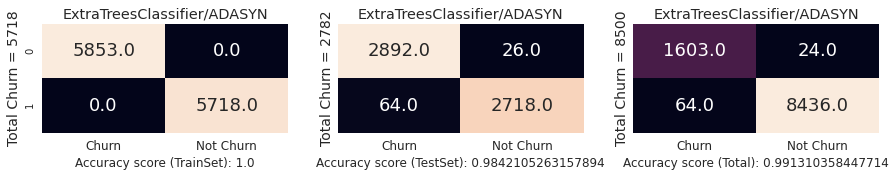

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9842105263157894
Overall Accuracy_Score   : 99.1310358447714 %
Recall ratio             : 99.24705882352941 %
AUC score                : 98.88597563180159 %
CPU times: user 3.48 s, sys: 19.4 ms, total: 3.5 s
Wall time: 3.49 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [60]:
title = 'ExtraTreesClassifier/ADASYN'
%time Models(ExtraTreesClassifier(),X_train4, X_test4, y_train4, y_test4, title, True)

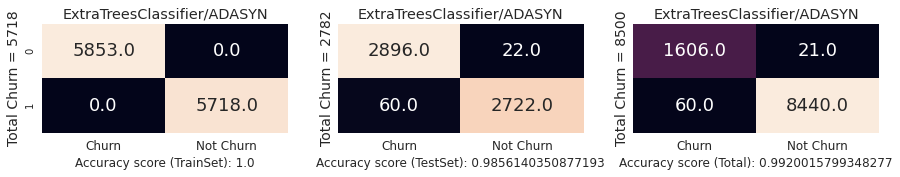

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9856140350877193
Overall Accuracy_Score   : 99.20015799348278 %
Recall ratio             : 99.29411764705883 %
AUC score                : 99.00169926606168 %
CPU times: user 9.77 s, sys: 65.8 ms, total: 9.84 s
Wall time: 9.83 s


(array([1, 1, 1, ..., 0, 0, 0]), array([1, 1, 1, ..., 0, 0, 0]))

In [61]:
title = 'ExtraTreesClassifier/ADASYN'
%time Models(ExtraTreesClassifier(n_estimators=305),X_train4, X_test4, y_train4, y_test4, title, True)

# For conclusion, ExtraTreesClassifier is the recommended model for this topic.
+ Model | Training set | Testing set | Overal |
+ KNeighborsClassifier: | 100% | 91.1% | 96.3% |
+ DecisionTreeClassifier: | 99.6% | 95.3% | 97.6% | 
+ RandomForestClassifier: | 100% | 97.9% | 98.9% | 
+ GradientBoostingClassifier: | 100% | 98.4% | 99.1% |
+ XGBClassifier: | 100% | 98.5% | 99.2% | 
+ LGBMClassifier: | 100% | 98.5% | 99.2% |
+ GradientBoostingClassifier: | 99.7% | 98.2% | 98.7% |
+ ExtraTreesClassifier: | 100% | 98.4% | 99.1% | ===> THIS IS THE BEST ONE

		Error Table
Accuracy on Traing set   :  1.0
Accuracy on Testing set  :  0.9795008912655971
Overall Accuracy_Score   : 98.93354399131036 %
Recall ratio             : 99.31764705882354 %
AUC score                : 98.12225315448858 %


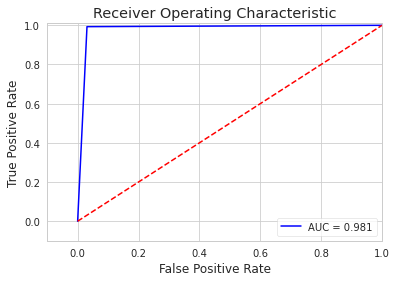

In [62]:
from sklearn.metrics import confusion_matrix,auc,roc_curve

title = 'RandomForestClassifier using the SMOTE'
y, ypred =  Models(RandomForestClassifier(),X_train1, X_test1, y_train1, y_test1, title, False)

fpr, tpr, thresholds = roc_curve(y, ypred)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b',label='AUC = %0.3f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.1,1.0])
plt.ylim([-0.1,1.01])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

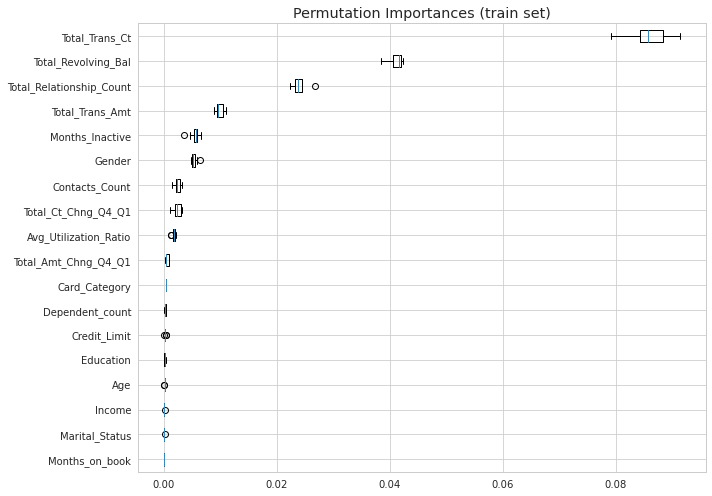

In [63]:
X=df_train.drop(columns=['Attrition'])
y=df_train['Attrition'].values
    
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 25)
    
model = ExtraTreesClassifier()
model.fit(X_train,y_train)
resultmymodel = permutation_importance(model, X_train, y_train, n_repeats=10,random_state=42, n_jobs=2)
sorted_idx = resultmymodel.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10,7))
ax.boxplot(resultmymodel.importances[sorted_idx].T,vert=False, labels=X_train.columns[sorted_idx])
ax.set_title("Permutation Importances (train set)")
fig.tight_layout()
plt.show()

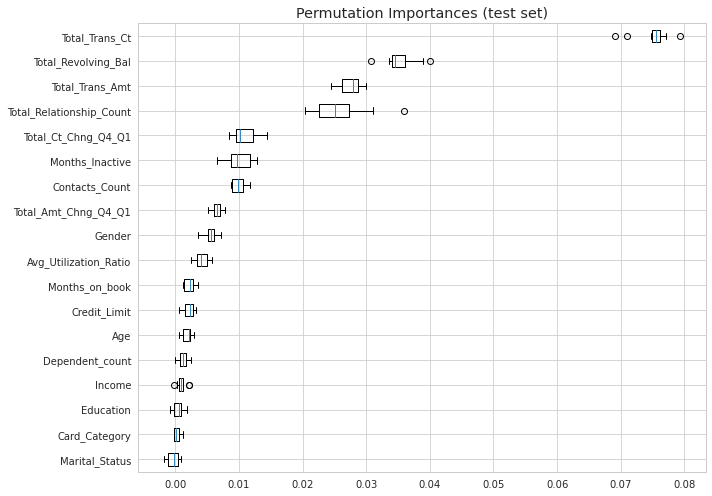

In [64]:
#X=df_train.drop(columns=['Attrition'])
#y=df_train['Attrition'].values
    
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 25)
    
#model = ExtraTreesClassifier()
#model.fit(X_test,y_test)
resultmymodel = permutation_importance(model, X_test, y_test, n_repeats=10,random_state=42, n_jobs=2)
sorted_idx = resultmymodel.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10,7))
ax.boxplot(resultmymodel.importances[sorted_idx].T,vert=False, labels=X_test.columns[sorted_idx])
ax.set_title("Permutation Importances (test set)")
fig.tight_layout()
plt.show()

# Conclusion

Customer churn prediction is crucial to the long-term financial stability of a company. In this Notebook, we successfully created a machine learning model that's able to predict customer churn with an accuracy higher than 98%.